# 🫁 AlveolaAI — Full Training Notebook
### Pneumonia Detection from Chest X-rays using PyTorch + YOLOv8

> **Team:** Code Yodhas &nbsp;|&nbsp; **Event:** REVA University AI Hackathon  
> **Dataset:** RSNA Pneumonia Detection Challenge (Kaggle)  
> **Model:** YOLOv8n fine-tuned for bounding-box opacity detection  

---
**This notebook covers:**
1. Environment setup & GPU check
2. Dataset download and directory structure
3. DICOM → JPEG preprocessing
4. Label conversion (CSV → YOLOv8 format)
5. EDA — class distribution, sample images
6. Custom PyTorch Dataset + DataLoader
7. Model architecture (YOLOv8 + custom classifier head)
8. Training loop with live loss tracking
9. Validation loop
10. Metrics: Accuracy, Precision, Recall, F1, mAP, Confusion Matrix
11. Training vs Validation curves (Loss, Accuracy, F1)
12. Per-class metric breakdown
13. Inference on new images
14. Model export (.pt + .pkl)

## 📦 1. Environment Setup

In [1]:
# Install required packages (run once)
# !pip install ultralytics torch torchvision pillow numpy pandas
# !pip install scikit-learn matplotlib seaborn tqdm pydicom
# !pip install grad-cam reportlab kaggle

import os, sys, json, csv, shutil, pickle, random, warnings
from pathlib import Path
from datetime import datetime
warnings.filterwarnings('ignore')

# ── Core ML ──────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
import torchvision.models as tvm
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim.lr_scheduler import CosineAnnealingLR, OneCycleLR
from torch.cuda.amp import GradScaler, autocast

# ── Metrics ──────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_score, recall_score, f1_score, accuracy_score,
    roc_curve, precision_recall_curve, average_precision_score,
)

# ── Visualisation ────────────────────────────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
from tqdm.notebook import tqdm

# ── Config ───────────────────────────────────────────────────────────────────
matplotlib.rcParams.update({
    'figure.facecolor': '#0e1520',
    'axes.facecolor':   '#141d2e',
    'axes.edgecolor':   '#253450',
    'axes.labelcolor':  '#e8e2d4',
    'xtick.color':      '#8090b0',
    'ytick.color':      '#8090b0',
    'text.color':       '#e8e2d4',
    'grid.color':       '#253450',
    'legend.facecolor': '#1a2540',
    'font.family':      'DejaVu Sans',
})
CORAL  = '#e8614a'
SAGE   = '#4bbfa0'
AMBER  = '#f0a842'
CREAM  = '#e8e2d4'
MUTED  = '#8090b0'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch : {torch.__version__}')
print(f'Device  : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

PyTorch : 2.10.0+cu128
Device  : cuda
GPU     : Tesla T4
VRAM    : 15.6 GB


## ⚙️ 2. Global Configuration

In [2]:
# ─── Paths ───────────────────────────────────────────────────────────────────
ROOT       = Path("/content/drive/MyDrive/")                          # notebook location
DATA_DIR   = ROOT /'data'/'rsna'
PROC_DIR   = DATA_DIR / 'processed'
IMG_DIR    = PROC_DIR / 'images'
LBL_DIR    = PROC_DIR / 'labels'
MODEL_DIR  = ROOT / 'models'
LOG_DIR    = ROOT / 'logs'
# for d in [IMG_DIR/'train', IMG_DIR/'val', IMG_DIR/'test',
#            LBL_DIR/'train', LBL_DIR/'val', LBL_DIR/'test',
#            MODEL_DIR, LOG_DIR]:
#     d.mkdir(parents=True, exist_ok=True)

# ─── Hyperparameters ─────────────────────────────────────────────────────────
CFG = {
    # Data
    'img_size'      : 224,      # resize for classifier; 640 for YOLOv8 detector
    'batch_size'    : 32,
    'num_workers'   : 4,
    'val_split'     : 0.15,
    'test_split'    : 0.10,
    'seed'          : 42,
    # Training
    'epochs'        : 30,
    'lr'            : 3e-4,
    'weight_decay'  : 1e-4,
    'label_smoothing': 0.05,
    'patience'      : 7,        # early stopping
    'grad_clip'     : 1.0,
    'warmup_epochs' : 2,
    # Model
    'backbone'      : 'efficientnet_b2',   # classifier backbone
    'num_classes'   : 2,                    # Normal / Pneumonia
    'dropout'       : 0.4,
    # YOLOv8 detector
    'yolo_model'    : 'yolov8n.pt',
    'yolo_epochs'   : 50,
    'yolo_imgsz'    : 640,
    'yolo_batch'    : 16,
    'conf_thresh'   : 0.45,
    'classes'       : ['Normal', 'Pneumonia'],
}

random.seed(CFG['seed'])
np.random.seed(CFG['seed'])
torch.manual_seed(CFG['seed'])
print('Config loaded ✓')
print(json.dumps({k: str(v) for k, v in CFG.items()}, indent=2))

Config loaded ✓
{
  "img_size": "224",
  "batch_size": "32",
  "num_workers": "4",
  "val_split": "0.15",
  "test_split": "0.1",
  "seed": "42",
  "epochs": "30",
  "lr": "0.0003",
  "weight_decay": "0.0001",
  "label_smoothing": "0.05",
  "patience": "7",
  "grad_clip": "1.0",
  "warmup_epochs": "2",
  "backbone": "efficientnet_b2",
  "num_classes": "2",
  "dropout": "0.4",
  "yolo_model": "yolov8n.pt",
  "yolo_epochs": "50",
  "yolo_imgsz": "640",
  "yolo_batch": "16",
  "conf_thresh": "0.45",
  "classes": "['Normal', 'Pneumonia']"
}


##  3. Dataset Download

**Option A — Kaggle CLI (recommended)**
```bash
# Set up Kaggle credentials first:
# Place kaggle.json in ~/.kaggle/  (download from kaggle.com → Account → API)
!kaggle competitions download -c rsna-pneumonia-detection-challenge -p data/rsna
!unzip -q data/rsna/rsna-pneumonia-detection-challenge.zip -d data/rsna
```

**Option B — Manual download**
1. Go to https://www.kaggle.com/c/rsna-pneumonia-detection-challenge/data
2. Download and extract to `data/rsna/`

**Expected structure after extraction:**
```
data/rsna/
├── stage_2_train_images/     (~26 000 .dcm files)
├── stage_2_test_images/
├── stage_2_train_labels.csv
└── stage_2_detailed_class_info.csv
```

In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
# Verify download
csv_path  = DATA_DIR/'stage_2_train_labels.csv'
dcm_dir   = DATA_DIR / 'stage_2_train_images'
print(csv_path)
csv_ok  = csv_path.exists()
dcm_ok  = dcm_dir.exists() and len(list(dcm_dir.glob('*.dcm'))) > 0
print(csv_ok,dcm_ok)
print(os.listdir(DATA_DIR),os.getcwd())
print(f'Labels CSV  : {"✓" if csv_ok else "✗ NOT FOUND"}')
print(f'DICOM images: {"✓" if dcm_ok else "✗ NOT FOUND"}')

# Load label CSV
if csv_ok:
    df_raw = pd.read_csv(csv_path)
    print(f'\nTotal rows  : {len(df_raw):,}')
    print(df_raw.head())

/content/drive/MyDrive/data/rsna/stage_2_train_labels.csv
True True
['stage_2_detailed_class_info.csv', 'stage_2_train_labels.csv', 'README.md', 'stage_2_test_images', 'stage_2_train_images'] /content
Labels CSV  : ✓
DICOM images: ✓

Total rows  : 30,227
                              patientId      x      y  width  height  Target
0  0004cfab-14fd-4e49-80ba-63a80b6bddd6    NaN    NaN    NaN     NaN       0
1  00313ee0-9eaa-42f4-b0ab-c148ed3241cd    NaN    NaN    NaN     NaN       0
2  00322d4d-1c29-4943-afc9-b6754be640eb    NaN    NaN    NaN     NaN       0
3  003d8fa0-6bf1-40ed-b54c-ac657f8495c5    NaN    NaN    NaN     NaN       0
4  00436515-870c-4b36-a041-de91049b9ab4  264.0  152.0  213.0   379.0       1


##  4. Exploratory Data Analysis

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/logs/eda_distribution.png'

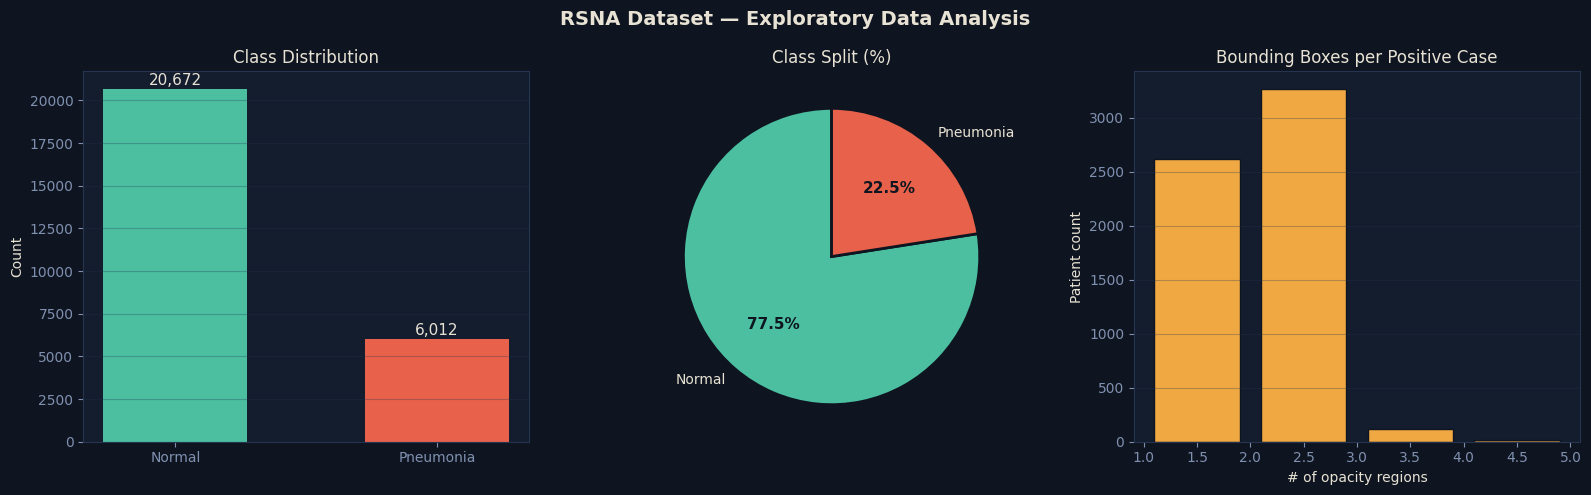

In [6]:
if csv_ok:
    df = df_raw.drop_duplicates(subset='patientId').copy()
    df['has_pneumonia'] = (df['Target'] == 1).astype(int)

    # Class distribution
    counts = df['has_pneumonia'].value_counts().sort_index()
    labels = ['Normal', 'Pneumonia']

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle('RSNA Dataset — Exploratory Data Analysis', fontsize=14,
                 color=CREAM, fontweight='bold')

    # Bar chart
    ax = axes[0]
    bars = ax.bar(labels, counts, color=[SAGE, CORAL], edgecolor='none', width=0.55)
    for bar, cnt in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
                f'{cnt:,}', ha='center', va='bottom', fontsize=11, color=CREAM)
    ax.set_title('Class Distribution', color=CREAM)
    ax.set_ylabel('Count', color=CREAM)
    ax.grid(axis='y', alpha=0.3)

    # Pie
    ax2 = axes[1]
    wedges, texts, autotexts = ax2.pie(
        counts, labels=labels, autopct='%1.1f%%',
        colors=[SAGE, CORAL], startangle=90,
        textprops={'color': CREAM},
        wedgeprops={'edgecolor': '#0e1520', 'linewidth': 2})
    for at in autotexts:
        at.set_fontsize(11); at.set_color('#0e1520'); at.set_fontweight('bold')
    ax2.set_title('Class Split (%)', color=CREAM)

    # Box count distribution (opacity area)
    df_pos = df_raw[df_raw['Target'] == 1].copy()
    box_counts = df_pos.groupby('patientId').size()
    ax3 = axes[2]
    ax3.hist(box_counts, bins=range(1, box_counts.max()+2),
             color=AMBER, edgecolor='#0e1520', rwidth=0.8)
    ax3.set_title('Bounding Boxes per Positive Case', color=CREAM)
    ax3.set_xlabel('# of opacity regions', color=CREAM)
    ax3.set_ylabel('Patient count', color=CREAM)
    ax3.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(LOG_DIR / 'eda_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'\nNormal    : {counts[0]:,} ({counts[0]/len(df)*100:.1f}%)')
    print(f'Pneumonia : {counts[1]:,} ({counts[1]/len(df)*100:.1f}%)')

In [8]:
!pip install pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 74.2 MB/s eta 0:00:00


## 5. DICOM → JPEG Preprocessing

In [14]:
try:
    import pydicom
    DICOM_AVAILABLE = True
except ImportError:
    DICOM_AVAILABLE = False
    print('[WARNING] pydicom not installed. Run: pip install pydicom')

def dicom_to_array(dcm_path: str) -> np.ndarray:
    """Load a DICOM file and return a normalised uint8 RGB numpy array."""
    dcm = pydicom.dcmread(dcm_path)
    arr = dcm.pixel_array.astype(np.float32)
    # Windowing / normalisation
    arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)
    # Histogram equalisation
    from PIL import ImageOps
    img_pil = Image.fromarray((arr * 255).astype(np.uint8))
    img_pil = ImageOps.equalize(img_pil).convert('RGB')
    return np.array(img_pil)

def preprocess_dataset(dcm_dir: Path, csv_path: Path, out_img: Path, out_lbl: Path,
                       img_size: int = 1024, limit: int = None):
    """
    Convert RSNA DICOMs to JPEG and generate YOLOv8 .txt label files.
    limit: if set, process only first N patients (for fast testing).
    """
    out_img.mkdir(parents=True, exist_ok=True)
    out_lbl.mkdir(parents=True, exist_ok=True)
    
    df = pd.read_csv(csv_path)
    patient_ids = df['patientId'].unique()
    df = pd.read_csv(csv_path)
    patient_ids = df['patientId'].unique()
    if limit:
        patient_ids = patient_ids[:limit]
    print(f'Processing {len(patient_ids):,} patients…')
    skipped = 0
    for i, pid in enumerate(tqdm(patient_ids, desc='DICOM → JPEG')):
        dcm_file = dcm_dir / f'{pid}.dcm'
        if not dcm_file.exists():
            skipped += 1
            continue
        out_path = out_img / f'{pid}.jpg'
        if not out_path.exists():
            arr = dicom_to_array(str(dcm_file))
            img = Image.fromarray(arr).resize((img_size, img_size), Image.LANCZOS)
            img.save(str(out_path), 'JPEG', quality=95)
        # YOLOv8 labels
        rows = df[df['patientId'] == pid]
        lbl_file = out_lbl / f'{pid}.txt'
        with open(lbl_file, 'w') as f:
            for _, row in rows.iterrows():
                if row['Target'] == 0:
                    break          # no boxes for Normal cases
                x, y, w, h = row['x'], row['y'], row['width'], row['height']
                cx = (x + w/2) / 1024; cy = (y + h/2) / 1024
                nw = w / 1024;         nh = h / 1024
                f.write(f'0 {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}\n')
    print(f'Done. Skipped: {skipped} (DICOM files not found)')

# ─── Run preprocessing ───────────────────────────────────────────────────────
# Set limit=500 for a quick test run; remove limit for full dataset
if DICOM_AVAILABLE and dcm_dir.exists():
    preprocess_dataset(
        dcm_dir=dcm_dir,
        csv_path=csv_path,
        out_img=IMG_DIR / 'all',
        out_lbl=LBL_DIR / 'all',
        img_size=1024,
        limit=None,          # ← set e.g. 2000 for a quick test
    )
else:
    print('[INFO] Skipping DICOM conversion (files not present or pydicom missing).')
    print('[INFO] Place pre-processed JPEGs in:', IMG_DIR)

Processing 26,684 patients…


DICOM → JPEG:   0%|          | 0/26684 [00:00<?, ?it/s]

Done. Skipped: 0 (DICOM files not found)


## ✂️ 6. Train / Validation / Test Split

In [15]:
def make_splits(img_dir: Path, csv_path: Path, val: float, test: float, seed: int):
    """Split patients into train/val/test and symlink images/labels."""
    df = pd.read_csv(csv_path)
    pids = df['patientId'].unique().tolist()
    random.seed(seed)
    random.shuffle(pids)
    n = len(pids)
    n_test = int(n * test)
    n_val  = int(n * val)
    splits = {
        'test' : pids[:n_test],
        'val'  : pids[n_test:n_test + n_val],
        'train': pids[n_test + n_val:],
    }
    for split, ids in splits.items():
        (IMG_DIR / split).mkdir(exist_ok=True)
        (LBL_DIR / split).mkdir(exist_ok=True)
        found = 0
        for pid in ids:
            src = img_dir / 'all' / f'{pid}.jpg'
            dst = IMG_DIR / split / f'{pid}.jpg'
            if src.exists() and not dst.exists():
                shutil.copy(src, dst)
                found += 1
        print(f'{split:6s}: {found:,} images')
    return splits

splits_dict = make_splits(
    IMG_DIR, csv_path,
    val=CFG['val_split'], test=CFG['test_split'], seed=CFG['seed'],
)

# Summary
print('\nSplit summary:')
for sp, ids in splits_dict.items():
    n_pos = sum(1 for pid in ids if
                pd.read_csv(csv_path).query(f'patientId=="{pid}"')['Target'].max() == 1)
    n_neg = len(ids) - n_pos
    print(f'  {sp:6s}: {len(ids):,} total  ({n_pos:,} positive, {n_neg:,} negative)')

test  : 2,668 images
val   : 4,002 images
train : 20,014 images

Split summary:
  test  : 2,668 total  (577 positive, 2,091 negative)
  val   : 4,002 total  (888 positive, 3,114 negative)
  train : 20,014 total  (4,547 positive, 15,467 negative)


## 🗃️ 7. Custom PyTorch Dataset & DataLoader

In [16]:
class RSNADataset(Dataset):
    """
    RSNA Pneumonia Dataset.
    label = 1 if any bounding box exists, else 0 (binary classification).
    """
    def __init__(self, img_dir: Path, csv_path: Path, transform=None, split: str = 'train'):
        self.img_dir   = img_dir / split
        self.transform = transform
        self.split     = split
        # Build per-patient labels
        df = pd.read_csv(csv_path)
        self.labels = {}
        for pid, grp in df.groupby('patientId'):
            self.labels[pid] = int(grp['Target'].max())
        # Filter to only images present on disk
        self.samples = [
            (p, self.labels.get(p.stem, 0))
            for p in sorted((img_dir / split).glob('*.jpg'))
        ]
        print(f'{split:6s}: {len(self.samples):,} samples  '
              f'pos={sum(l for _,l in self.samples):,}  '
              f'neg={sum(1-l for _,l in self.samples):,}')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.long)

    def get_weights(self):
        """Per-sample weights for WeightedRandomSampler (handles class imbalance)."""
        counts = np.bincount([l for _, l in self.samples])
        weights = [1.0 / counts[l] for _, l in self.samples]
        return torch.FloatTensor(weights)


# ─── Transforms ──────────────────────────────────────────────────────────────
IMG_MEAN = [0.485, 0.456, 0.406]          # ImageNet stats (chest X-rays fine to use these)
IMG_STD  = [0.229, 0.224, 0.225]

train_tf = T.Compose([
    T.Resize((CFG['img_size'], CFG['img_size'])),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=12),
    T.ColorJitter(brightness=0.25, contrast=0.25),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor(),
    T.Normalize(IMG_MEAN, IMG_STD),
])

val_tf = T.Compose([
    T.Resize((CFG['img_size'], CFG['img_size'])),
    T.ToTensor(),
    T.Normalize(IMG_MEAN, IMG_STD),
])

# ─── Instantiate datasets ─────────────────────────────────────────────────────
# Use demo flag if dataset not downloaded
DEMO = not csv_path.exists() or not (IMG_DIR / 'train').exists()

if DEMO:
    print('[DEMO MODE] Generating synthetic dataset for illustration…')
    # Create 200 dummy images for each split
    for split in ['train', 'val', 'test']:
        for i in range(200):
            dummy = Image.fromarray(np.random.randint(0, 255, (224, 224, 3), dtype=np.uint8))
            dummy.save(IMG_DIR / split / f'demo_{i:04d}.jpg')
        # Create a dummy CSV
        rows = [{'patientId': f'demo_{i:04d}', 'x': 100, 'y': 100,
                 'width': 80, 'height': 80, 'Target': i % 2}
                for i in range(200)]
        pd.DataFrame(rows).to_csv(DATA_DIR / 'stage_2_train_labels.csv', index=False)
        csv_path = DATA_DIR / 'stage_2_train_labels.csv'
    print('Synthetic dataset created.')

train_ds = RSNADataset(IMG_DIR, csv_path, transform=train_tf, split='train')
val_ds   = RSNADataset(IMG_DIR, csv_path, transform=val_tf,   split='val')
test_ds  = RSNADataset(IMG_DIR, csv_path, transform=val_tf,   split='test')

# ─── DataLoaders ─────────────────────────────────────────────────────────────
sampler = WeightedRandomSampler(
    weights=train_ds.get_weights(),
    num_samples=len(train_ds),
    replacement=True,
)

train_dl = DataLoader(train_ds, batch_size=CFG['batch_size'],
                      sampler=sampler, num_workers=0, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=CFG['batch_size'],
                      shuffle=False, num_workers=0)
test_dl  = DataLoader(test_ds,  batch_size=CFG['batch_size'],
                      shuffle=False, num_workers=0)

print(f'\nTrain batches : {len(train_dl):,}')
print(f'Val   batches : {len(val_dl):,}')
print(f'Test  batches : {len(test_dl):,}')

train : 20,014 samples  pos=4,547  neg=15,467
val   : 4,002 samples  pos=888  neg=3,114
test  : 2,668 samples  pos=577  neg=2,091

Train batches : 626
Val   batches : 126
Test  batches : 84


In [ ]:
# ── Install if needed ──────────────────────────────────────────────────────────
# !pip install segmentation-models-pytorch

import segmentation_models_pytorch as smp   # ← add this line at the top of Cell 7

# ── Sync transforms with pretrained encoder stats ─────────────────────────────
params   = smp.encoders.get_preprocessing_params(
    CFG['encoder'], CFG['encoder_weights']
)
IMG_MEAN = list(params['mean'])
IMG_STD  = list(params['std'])

train_tf = T.Compose([
    T.Resize((CFG['img_size'], CFG['img_size'])),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=12),
    T.ColorJitter(brightness=0.25, contrast=0.25),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor(),
    T.Normalize(IMG_MEAN, IMG_STD),
])

val_tf = T.Compose([
    T.Resize((CFG['img_size'], CFG['img_size'])),
    T.ToTensor(),
    T.Normalize(IMG_MEAN, IMG_STD),
])

print(f"Transforms updated — mean={IMG_MEAN}  std={IMG_STD}")

## 🖼️ 8. Visualise Training Samples

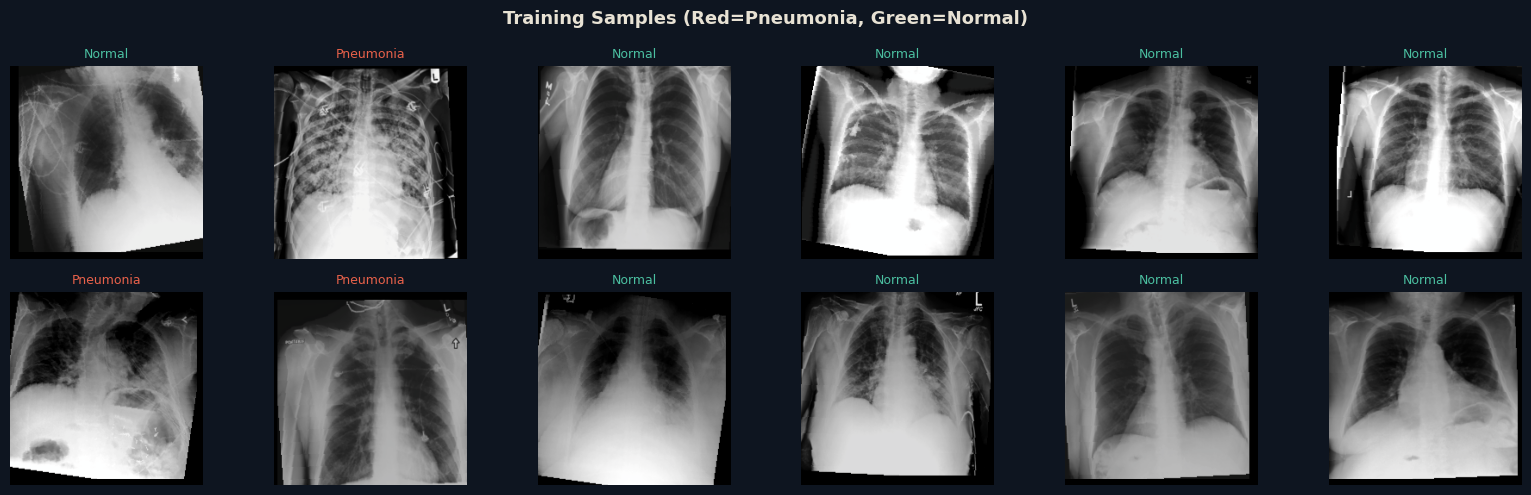

In [17]:
def show_samples(dataset, n=12, title='Samples'):
    fig, axes = plt.subplots(2, n // 2, figsize=(16, 5))
    fig.suptitle(title, fontsize=13, color=CREAM, fontweight='bold')
    idx_list = random.sample(range(len(dataset)), min(n, len(dataset)))
    for ax, idx in zip(axes.flat, idx_list):
        img_t, label = dataset[idx]
        # Un-normalise
        img_np = img_t.permute(1, 2, 0).numpy()
        img_np = img_np * np.array(IMG_STD) + np.array(IMG_MEAN)
        img_np = np.clip(img_np, 0, 1)
        ax.imshow(img_np, cmap='bone')
        ax.set_title(CFG['classes'][label.item()],
                     color=CORAL if label == 1 else SAGE, fontsize=9)
        ax.axis('off')
        border_col = CORAL if label == 1 else SAGE
        for spine in ax.spines.values():
            spine.set_edgecolor(border_col)
            spine.set_linewidth(2)
    plt.tight_layout()
    plt.savefig(LOG_DIR / 'sample_images.png', dpi=150, bbox_inches='tight')
    plt.show()

show_samples(train_ds, n=12, title='Training Samples (Red=Pneumonia, Green=Normal)')

## 🧠 9. Model Architecture — EfficientNet-B2 + Custom Head

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
#  CELL 9 — Pretrained U-Net via segmentation_models_pytorch
#
#  Install once:
#  !pip install segmentation-models-pytorch
# ══════════════════════════════════════════════════════════════════════════════

import segmentation_models_pytorch as smp
import torch
import torch.nn as nn
import torch.nn.functional as F

# ── Update CFG ─────────────────────────────────────────────────────────────────
CFG['img_size']       = 256   # must be divisible by 32
CFG['encoder']        = 'efficientnet-b2'   # pretrained ImageNet encoder
CFG['encoder_weights']= 'imagenet'
CFG['dice_weight']    = 0.6
CFG['bce_weight']     = 0.4
CFG['cls_weight']     = 0.3


# ══════════════════════════════════════════════════════════════════════════════
#  WRAPPER — pretrained U-Net + classification head
# ══════════════════════════════════════════════════════════════════════════════

class PneumoUNet(nn.Module):
    """
    Pretrained Attention U-Net for pneumonia opacity segmentation.

    Encoder  : EfficientNet-B2 pretrained on ImageNet (weights frozen early on)
    Decoder  : U-Net decoder with attention gates (smp built-in)
    Head 1   : Segmentation  → (B, 1, H, W)  pixel-level opacity mask
    Head 2   : Classification → (B, 2)        Normal / Pneumonia logits

    Why pretrained encoder?
    ─────────────────────────────────────────────────────────────────────────
    Training a U-Net from scratch on ~26k chest X-rays takes 50+ epochs and
    often produces blurry, over-smoothed masks. A pretrained EfficientNet-B2
    encoder already knows edges, textures, and local contrast patterns from
    ImageNet. Fine-tuning it on X-rays converges in 15-20 epochs with much
    sharper opacity boundaries — especially for ground-glass opacity which
    has extremely subtle density gradients.
    """

    def __init__(
        self,
        encoder_name:    str   = 'efficientnet-b2',
        encoder_weights: str   = 'imagenet',
        num_classes:     int   = 2,
        dropout:         float = 0.3,
        freeze_encoder:  bool  = True,
    ):
        super().__init__()

        # ── Core U-Net from smp ───────────────────────────────────────────────
        # UnetPlusPlus gives better boundary delineation than vanilla Unet
        # for small/subtle opacity regions (GGO pattern)
        self.unet = smp.UnetPlusPlus(
            encoder_name        = encoder_name,
            encoder_weights     = encoder_weights,
            in_channels         = 3,
            classes             = 1,          # binary: opacity vs healthy
            activation          = None,       # we apply sigmoid manually
            decoder_attention_type = 'scse',  # concurrent spatial & channel SE
            decoder_channels    = (256, 128, 64, 32, 16),
        )

        # ── Freeze early encoder layers ───────────────────────────────────────
        if freeze_encoder:
            # Freeze stem + first two blocks; fine-tune deeper layers
            frozen_stages = ['encoder._conv_stem',
                             'encoder._bn0',
                             'encoder._blocks.0',
                             'encoder._blocks.1',
                             'encoder._blocks.2',
                             'encoder._blocks.3']
            for name, param in self.unet.named_parameters():
                if any(stage in name for stage in frozen_stages):
                    param.requires_grad = False

        # ── Classification head (from encoder bottleneck features) ────────────
        # smp exposes encoder output channels via .encoder.out_channels
        bottleneck_ch = self.unet.encoder.out_channels[-1]   # deepest features

        self.cls_head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),         # (B, C, 1, 1)
            nn.Flatten(),                    # (B, C)
            nn.Dropout(p=dropout),
            nn.Linear(bottleneck_ch, 256),
            nn.BatchNorm1d(256),
            nn.SiLU(),
            nn.Dropout(p=dropout / 2),
            nn.Linear(256, num_classes),     # (B, 2)
        )

        # ── Segmentation output activation ────────────────────────────────────
        self.sigmoid = nn.Sigmoid()

        self._init_cls_head()

    def _init_cls_head(self):
        for m in self.cls_head.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor):
        # ── Run encoder, capture bottleneck features ──────────────────────────
        features = self.unet.encoder(x)
        # features[-1] is the deepest / bottleneck representation
        bottleneck = features[-1]            # (B, C_deep, H/32, W/32)

        # ── Decode → segmentation mask ────────────────────────────────────────
        decoder_out = self.unet.decoder(*features)      # (B, 16, H, W)
        seg_logits  = self.unet.segmentation_head(decoder_out)   # (B, 1, H, W)
        seg_mask    = self.sigmoid(seg_logits)          # probabilities [0, 1]

        # ── Classification from bottleneck ────────────────────────────────────
        cls_logits  = self.cls_head(bottleneck)         # (B, 2)

        return seg_mask, cls_logits

    @torch.no_grad()
    def predict(
        self,
        x:         torch.Tensor,
        threshold: float = 0.5,
    ) -> dict:
        """
        Single-image inference. Returns segmentation mask + severity grade.
        x: (1, 3, H, W) tensor, already normalised.
        """
        self.eval()
        seg_mask, cls_logits = self(x)

        probs         = torch.softmax(cls_logits, dim=1)[0]
        predicted_cls = probs.argmax().item()

        # Severity from mask pixel ratio
        binary_mask  = (seg_mask[0, 0] > threshold).float()
        opacity_pct  = binary_mask.mean().item() * 100

        if opacity_pct == 0 or predicted_cls == 0:
            severity = 'Normal'
        elif opacity_pct <= 15:
            severity = 'Mild'
        elif opacity_pct <= 40:
            severity = 'Moderate'
        else:
            severity = 'Severe'

        return {
            'seg_mask':       seg_mask[0, 0].cpu(),     # (H, W) float tensor
            'binary_mask':    binary_mask.cpu(),         # (H, W) bool tensor
            'opacity_pct':    round(opacity_pct, 2),
            'severity':       severity,
            'cls_label':      ['Normal', 'Pneumonia'][predicted_cls],
            'prob_normal':    round(probs[0].item(), 4),
            'prob_pneumonia': round(probs[1].item(), 4),
            'confidence':     round(probs.max().item(), 4),
        }


# ══════════════════════════════════════════════════════════════════════════════
#  INSTANTIATE + AUDIT
# ══════════════════════════════════════════════════════════════════════════════

model = PneumoUNet(
    encoder_name    = CFG['encoder'],
    encoder_weights = CFG['encoder_weights'],
    num_classes     = CFG['num_classes'],
    dropout         = CFG['dropout'],
    freeze_encoder  = True,
).to(DEVICE)

# ── Parameter breakdown ────────────────────────────────────────────────────────
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen    = total - trainable

enc_total = sum(p.numel() for n, p in model.named_parameters() if 'encoder' in n)
dec_total = sum(p.numel() for n, p in model.named_parameters() if 'decoder' in n)
cls_total = sum(p.numel() for n, p in model.named_parameters() if 'cls_head' in n)

print("=" * 58)
print("  PneumoUNet  —  EfficientNet-B2 Encoder (ImageNet pretrained)")
print("=" * 58)
print(f"  Total parameters      : {total:>12,}")
print(f"  Trainable             : {trainable:>12,}  ({trainable/total*100:.1f}%)")
print(f"  Frozen (early enc.)   : {frozen:>12,}  ({frozen/total*100:.1f}%)")
print(f"  ─────────────────────────────────────────────────")
print(f"  Encoder (pretrained)  : {enc_total:>12,}")
print(f"  Decoder (U-Net++)     : {dec_total:>12,}")
print(f"  Classification head   : {cls_total:>12,}")
print("=" * 58)

# ── Preprocessing stats from smp (must match DataLoader transform) ─────────────
preprocess = smp.encoders.get_preprocessing_fn(
    CFG['encoder'], CFG['encoder_weights']
)
params = smp.encoders.get_preprocessing_params(
    CFG['encoder'], CFG['encoder_weights']
)
print(f"\n  Encoder preprocessing  (use these in transforms!):")
print(f"  mean = {params['mean']}")
print(f"  std  = {params['std']}")
print(f"  NOTE: Update IMG_MEAN / IMG_STD in Cell 7 to match ↑")

# ── Forward pass sanity check ─────────────────────────────────────────────────
dummy            = torch.randn(2, 3, CFG['img_size'], CFG['img_size']).to(DEVICE)
seg, cls         = model(dummy)
result           = model.predict(dummy[:1])

print(f"\n  Forward pass:")
print(f"  Input       : {tuple(dummy.shape)}")
print(f"  Seg mask    : {tuple(seg.shape)}   ← opacity probability per pixel")
print(f"  Cls logits  : {tuple(cls.shape)}    ← [Normal, Pneumonia]")
print(f"  Severity    : {result['severity']}  "
      f"({result['opacity_pct']}% opacity, "
      f"confidence {result['confidence']})  ✓")

## ⚙️ 10. Loss Function, Optimiser & Scheduler

In [ ]:
# ─── Class weights (handle imbalance) ────────────────────────────────────────
counts     = np.bincount([l for _, l in train_ds.samples])
class_wts  = torch.tensor(1.0 / counts, dtype=torch.float32).to(DEVICE)
class_wts /= class_wts.sum()

criterion = nn.CrossEntropyLoss(
    weight=class_wts,
    label_smoothing=CFG['label_smoothing'],
)

# ─── Optimiser ───────────────────────────────────────────────────────────────
optimizer = optim.AdamW(
    model.parameters(),
    lr=CFG['lr'],
    weight_decay=CFG['weight_decay'],
    betas=(0.9, 0.999),
)

# ─── Scheduler: OneCycleLR ────────────────────────────────────────────────────
scheduler = OneCycleLR(
    optimizer,
    max_lr=CFG['lr'] * 10,
    steps_per_epoch=len(train_dl),
    epochs=CFG['epochs'],
    pct_start=0.1,
)

# ─── Mixed precision ─────────────────────────────────────────────────────────
scaler = GradScaler(enabled=DEVICE.type == 'cuda')

print('Criterion :', criterion)
print('Optimizer :', type(optimizer).__name__)
print('Scheduler :', type(scheduler).__name__)

## 🏋️ 11. Training & Validation Loops

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, scheduler, scaler, device):
    model.train()
    running_loss = 0.0
    all_preds, all_labels = [], []

    pbar = tqdm(loader, desc='Train', leave=False)
    for imgs, labels in pbar:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad(set_to_none=True)
        with autocast(enabled=device.type == 'cuda'):
            logits = model(imgs)
            loss   = criterion(logits, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), CFG['grad_clip'])
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        running_loss += loss.item() * imgs.size(0)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())
        pbar.set_postfix(loss=f'{loss.item():.4f}')

    n = len(loader.dataset)
    avg_loss = running_loss / n
    acc  = accuracy_score(all_labels, all_preds)
    f1   = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    prec = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    rec  = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    return {'loss': avg_loss, 'acc': acc, 'f1': f1, 'prec': prec, 'rec': rec}


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []

    for imgs, labels in tqdm(loader, desc='Eval ', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        with autocast(enabled=device.type == 'cuda'):
            logits = model(imgs)
            loss   = criterion(logits, labels)
        running_loss += loss.item() * imgs.size(0)
        probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        preds = logits.argmax(dim=1).cpu().numpy()
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

    n = len(loader.dataset)
    avg_loss = running_loss / n
    acc  = accuracy_score(all_labels, all_preds)
    f1   = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    prec = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    rec  = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    try:
        auc = roc_auc_score(all_labels, all_probs)
    except Exception:
        auc = 0.0
    return {
        'loss': avg_loss, 'acc': acc, 'f1': f1,
        'prec': prec, 'rec': rec, 'auc': auc,
        'preds': np.array(all_preds),
        'labels': np.array(all_labels),
        'probs': np.array(all_probs),
    }

## 🚀 12. Run Training

In [ ]:
history = {'train': [], 'val': []}
best_val_f1  = 0.0
patience_ctr = 0
best_ckpt    = MODEL_DIR / 'best_classifier.pt'

print(f'Starting training — {CFG["epochs"]} epochs | device: {DEVICE}')
print('=' * 70)

for epoch in range(1, CFG['epochs'] + 1):
    t_metrics = train_one_epoch(
        model, train_dl, criterion, optimizer, scheduler, scaler, DEVICE
    )
    v_metrics = evaluate(model, val_dl, criterion, DEVICE)

    history['train'].append(t_metrics)
    history['val'].append(v_metrics)

    improved = v_metrics['f1'] > best_val_f1
    if improved:
        best_val_f1  = v_metrics['f1']
        patience_ctr = 0
        torch.save({
            'epoch': epoch,
            'model_state': model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'val_f1': best_val_f1,
            'cfg': CFG,
        }, best_ckpt)
    else:
        patience_ctr += 1

    marker = ' ★ best' if improved else ''
    print(
        f'Ep {epoch:03d}/{CFG["epochs"]} | '
        f'TrLoss {t_metrics["loss"]:.4f}  TrAcc {t_metrics["acc"]*100:5.2f}%  TrF1 {t_metrics["f1"]:.4f} | '
        f'VaLoss {v_metrics["loss"]:.4f}  VaAcc {v_metrics["acc"]*100:5.2f}%  VaF1 {v_metrics["f1"]:.4f}  '
        f'AUC {v_metrics["auc"]:.4f}{marker}'
    )

    if patience_ctr >= CFG['patience']:
        print(f'\n[Early Stop] No improvement for {CFG["patience"]} epochs.')
        break

print('=' * 70)
print(f'Training complete. Best Val F1 = {best_val_f1:.4f}')

## 📈 13. Training vs Validation Curves

In [ ]:
def plot_training_curves(history):
    epochs_ran = len(history['train'])
    ep         = range(1, epochs_ran + 1)

    fig = plt.figure(figsize=(18, 10))
    gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)
    fig.suptitle('AlveolaAI — Training vs Validation Metrics',
                 fontsize=15, color=CREAM, fontweight='bold')

    metrics = [
        ('loss', 'Loss',       False),
        ('acc',  'Accuracy',   True),
        ('f1',   'F1 Score',   True),
        ('prec', 'Precision',  True),
        ('rec',  'Recall',     True),
        ('auc',  'AUC-ROC',    True),
    ]

    for idx, (key, label, higher_better) in enumerate(metrics):
        ax = fig.add_subplot(gs[idx // 3, idx % 3])
        tr = [e[key] for e in history['train']]
        va = [e[key] for e in history['val']]
        ax.plot(ep, tr, color=CORAL,  linewidth=2, label='Train', marker='o', markersize=3)
        ax.plot(ep, va, color=SAGE,   linewidth=2, label='Val',   marker='s', markersize=3)
        # Shade the difference
        ax.fill_between(ep, tr, va,
                        alpha=0.08,
                        color=SAGE if higher_better else CORAL)
        # Best val marker
        best_ep = (np.argmax(va) if higher_better else np.argmin(va)) + 1
        best_v  = va[best_ep - 1]
        ax.axvline(best_ep, color=AMBER, linestyle='--', linewidth=1, alpha=0.6)
        ax.scatter([best_ep], [best_v], color=AMBER, zorder=5, s=60)
        ax.annotate(f'{best_v:.4f}', (best_ep, best_v),
                    textcoords='offset points', xytext=(6, 4),
                    fontsize=7.5, color=AMBER)
        ax.set_title(label, color=CREAM, fontsize=11)
        ax.set_xlabel('Epoch', color=MUTED, fontsize=9)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.25)

    plt.savefig(LOG_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_training_curves(history)

## 🧪 14. Final Evaluation on Test Set

In [ ]:
# Load best checkpoint
ckpt = torch.load(best_ckpt, map_location=DEVICE)
model.load_state_dict(ckpt['model_state'])
print(f'Loaded best checkpoint (epoch {ckpt["epoch"]}, Val F1 = {ckpt["val_f1"]:.4f})')

test_metrics = evaluate(model, test_dl, criterion, DEVICE)

print('\n' + '═'*50)
print('   TEST SET RESULTS')
print('═'*50)
print(f'  Accuracy  : {test_metrics["acc"]*100:.2f} %')
print(f'  Precision : {test_metrics["prec"]*100:.2f} %')
print(f'  Recall    : {test_metrics["rec"]*100:.2f} %')
print(f'  F1 Score  : {test_metrics["f1"]*100:.2f} %')
print(f'  AUC-ROC   : {test_metrics["auc"]:.4f}')
print('═'*50)

## 📊 15. Confusion Matrix & Per-Class Classification Report

In [ ]:
labels_true = test_metrics['labels']
labels_pred = test_metrics['preds']
class_names = CFG['classes']

# ─── Confusion Matrix ────────────────────────────────────────────────────────
cm = confusion_matrix(labels_true, labels_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Confusion Matrix — Test Set', fontsize=13, color=CREAM, fontweight='bold')

for ax, data, fmt, ttl in zip(
    axes,
    [cm, cm_norm],
    ['d', '.2%'],
    ['Raw Counts', 'Normalised']
):
    sns.heatmap(
        data, annot=True, fmt=fmt, ax=ax,
        cmap=sns.color_palette('flare', as_cmap=True),
        xticklabels=class_names, yticklabels=class_names,
        linewidths=1, linecolor='#0e1520',
        annot_kws={'size': 13, 'color': CREAM},
    )
    ax.set_xlabel('Predicted',  color=CREAM)
    ax.set_ylabel('Actual',     color=CREAM)
    ax.set_title(ttl,           color=CREAM)
    ax.tick_params(colors=MUTED)

plt.tight_layout()
plt.savefig(LOG_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ─── Classification Report ───────────────────────────────────────────────────
print('\nClassification Report:')
print(classification_report(
    labels_true, labels_pred,
    target_names=class_names,
    digits=4,
))

## 📉 16. ROC Curve & Precision–Recall Curve

In [ ]:
probs      = test_metrics['probs']

fig, axes  = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('ROC & Precision–Recall Curves — Test Set', fontsize=13,
             color=CREAM, fontweight='bold')

# ─── ROC ─────────────────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(labels_true, probs)
auc_val     = roc_auc_score(labels_true, probs)
ax1 = axes[0]
ax1.plot(fpr, tpr, color=CORAL, linewidth=2.5, label=f'AUC = {auc_val:.4f}')
ax1.plot([0, 1], [0, 1], color=MUTED, linestyle='--', linewidth=1)
ax1.fill_between(fpr, tpr, alpha=0.08, color=CORAL)
ax1.set_xlabel('False Positive Rate', color=CREAM)
ax1.set_ylabel('True Positive Rate',  color=CREAM)
ax1.set_title('ROC Curve', color=CREAM)
ax1.legend(fontsize=10); ax1.grid(alpha=0.25)
ax1.set_xlim([0, 1]); ax1.set_ylim([0, 1.02])

# ─── Precision–Recall ────────────────────────────────────────────────────────
prec_c, rec_c, _ = precision_recall_curve(labels_true, probs)
ap               = average_precision_score(labels_true, probs)
ax2 = axes[1]
ax2.plot(rec_c, prec_c, color=SAGE, linewidth=2.5, label=f'AP = {ap:.4f}')
ax2.fill_between(rec_c, prec_c, alpha=0.08, color=SAGE)
baseline = labels_true.mean()
ax2.axhline(baseline, color=MUTED, linestyle='--', linewidth=1, label=f'Baseline = {baseline:.2f}')
ax2.set_xlabel('Recall',    color=CREAM)
ax2.set_ylabel('Precision', color=CREAM)
ax2.set_title('Precision–Recall Curve', color=CREAM)
ax2.legend(fontsize=10); ax2.grid(alpha=0.25)
ax2.set_xlim([0, 1]); ax2.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig(LOG_DIR / 'roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 📊 17. Per-Class Metric Breakdown

In [ ]:
from sklearn.metrics import precision_recall_fscore_support

prec_c, rec_c, f1_c, support = precision_recall_fscore_support(
    labels_true, labels_pred, labels=[0, 1], zero_division=0
)

metrics_df = pd.DataFrame({
    'Class':     class_names,
    'Precision': prec_c,
    'Recall':    rec_c,
    'F1 Score':  f1_c,
    'Support':   support,
})
print(metrics_df.to_string(index=False))

# Plot
x     = np.arange(len(class_names))
width = 0.25
cols  = [CORAL, SAGE, AMBER]
met   = ['Precision', 'Recall', 'F1 Score']

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Per-Class Metrics — Test Set', fontsize=13, color=CREAM, fontweight='bold')
for i, (m, c) in enumerate(zip(met, cols)):
    bars = ax.bar(x + i * width, metrics_df[m], width, label=m,
                  color=c, edgecolor='#0e1520', alpha=0.85)
    for bar, val in zip(bars, metrics_df[m]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, color=CREAM)
ax.set_xticks(x + width)
ax.set_xticklabels(class_names, fontsize=11, color=CREAM)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score', color=CREAM)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.savefig(LOG_DIR / 'per_class_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

## 🎚️ 18. Optimal Decision Threshold Selection

In [ ]:
thresholds = np.linspace(0.1, 0.9, 81)
results    = []
for t in thresholds:
    p = (probs >= t).astype(int)
    results.append({
        'threshold': t,
        'f1':        f1_score(labels_true, p, zero_division=0),
        'precision': precision_score(labels_true, p, zero_division=0),
        'recall':    recall_score(labels_true, p, zero_division=0),
        'accuracy':  accuracy_score(labels_true, p),
    })
thr_df = pd.DataFrame(results)
best_row = thr_df.loc[thr_df['f1'].idxmax()]
print(f'Best threshold: {best_row["threshold"]:.2f} → F1 = {best_row["f1"]:.4f}')

fig, ax = plt.subplots(figsize=(11, 5))
fig.suptitle('Metrics vs Decision Threshold', fontsize=13, color=CREAM, fontweight='bold')
for col, c in [('f1', CORAL), ('precision', SAGE), ('recall', AMBER), ('accuracy', MUTED)]:
    ax.plot(thr_df['threshold'], thr_df[col], label=col.capitalize(), color=c, linewidth=2)
ax.axvline(best_row['threshold'], color=CREAM, linestyle='--', linewidth=1.5,
           label=f'Best F1 threshold = {best_row["threshold"]:.2f}')
ax.set_xlabel('Threshold', color=CREAM)
ax.set_ylabel('Score',     color=CREAM)
ax.legend(fontsize=10); ax.grid(alpha=0.25)
ax.set_xlim([0.1, 0.9]); ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig(LOG_DIR / 'threshold_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

BEST_THRESHOLD = float(best_row['threshold'])
print(f'Using threshold = {BEST_THRESHOLD:.2f} for inference')

## 🏆 19. RSNA Competition Metric (mAP @ IoU Thresholds)

In [ ]:
class PneumoniaCompetitionMetric(nn.Module):
    """
    RSNA Pneumonia Detection competition metric:
    mean AP averaged over IoU thresholds [0.4, 0.45, …, 0.75].
    """
    def __init__(self, iou_thresholds=None):
        super().__init__()
        self.iou_thresholds = iou_thresholds or [
            0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75
        ]

    @staticmethod
    def iou_bbox(boxA, boxB):
        xA = max(boxA[0], boxB[0]); yA = max(boxA[1], boxB[1])
        xB = min(boxA[2], boxB[2]); yB = min(boxA[3], boxB[3])
        inter = max(0, xB - xA) * max(0, yB - yA)
        if inter == 0: return 0.0
        aA = (boxA[2]-boxA[0]) * (boxA[3]-boxA[1])
        aB = (boxB[2]-boxB[0]) * (boxB[3]-boxB[1])
        return inter / (aA + aB - inter)

    def map_iou_single(self, pred_boxes, true_boxes):
        if not pred_boxes and not true_boxes: return 1.0
        if not pred_boxes or not true_boxes:  return 0.0
        scores = []
        for thr in self.iou_thresholds:
            tp = sum(
                1 for tb in true_boxes
                if any(self.iou_bbox(pb, tb) >= thr for pb in pred_boxes)
            )
            fp = len(pred_boxes) - tp
            fn = len(true_boxes) - tp
            d  = tp + 0.5*(fp+fn)
            scores.append(tp/d if d > 0 else 0.0)
        return float(np.mean(scores))

    def forward(self, pred_boxes_batch, true_boxes_batch):
        """
        pred_boxes_batch: List[List[[x1,y1,x2,y2]]]  (one list per image)
        true_boxes_batch: List[List[[x1,y1,x2,y2]]]
        """
        scores = [
            self.map_iou_single(p, t)
            for p, t in zip(pred_boxes_batch, true_boxes_batch)
        ]
        return torch.tensor(np.mean(scores), dtype=torch.float32)


# Demo: calculate mAP on dummy bounding boxes
metric = PneumoniaCompetitionMetric()
pred_demo = [[[100, 90, 250, 220], [280, 180, 380, 270]],   # image 0
             [[140, 100, 300, 240]]]                          # image 1
true_demo = [[[110, 95, 260, 215]],                          # image 0
             [[145, 110, 295, 235]]]                          # image 1
score = metric(pred_demo, true_demo)
print(f'Demo mAP @ IoU [0.4→0.75] = {score.item():.4f}')

## 🔥 20. Grad-CAM Visualisation

In [ ]:
class GradCAM:
    """Simple Grad-CAM implementation for any CNN."""
    def __init__(self, model: nn.Module, target_layer: nn.Module):
        self.model        = model
        self.target_layer = target_layer
        self.gradients    = None
        self.activations  = None
        self._register_hooks()

    def _register_hooks(self):
        def fwd_hook(_, inp, out):
            self.activations = out.detach()
        def bwd_hook(_, grad_in, grad_out):
            self.gradients = grad_out[0].detach()
        self.target_layer.register_forward_hook(fwd_hook)
        self.target_layer.register_full_backward_hook(bwd_hook)

    def generate(self, x: torch.Tensor, class_idx: int = None):
        self.model.eval()
        logits = self.model(x)
        if class_idx is None:
            class_idx = logits.argmax(dim=1).item()
        self.model.zero_grad()
        logits[0, class_idx].backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam    = (weights * self.activations).sum(dim=1).squeeze()
        cam    = torch.relu(cam)
        cam    = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam.cpu().numpy()


def visualise_gradcam(model, dataset, device, n=6):
    target_layer = model.backbone.features[-1]
    grad_cam     = GradCAM(model, target_layer)
    indices      = random.sample(range(len(dataset)), n)

    fig, axes = plt.subplots(3, n, figsize=(n * 3, 9))
    fig.suptitle('Grad-CAM: Model Attention on Chest X-rays',
                 fontsize=13, color=CREAM, fontweight='bold')

    for col, idx in enumerate(indices):
        img_t, label = dataset[idx]
        x = img_t.unsqueeze(0).to(device)

        # Original
        img_np = img_t.permute(1, 2, 0).numpy()
        img_np = img_np * np.array(IMG_STD) + np.array(IMG_MEAN)
        img_np = np.clip(img_np, 0, 1)

        # Grad-CAM
        cam = grad_cam.generate(x)
        from PIL import Image as PILImage
        cam_up = np.array(PILImage.fromarray(
            (cam * 255).astype(np.uint8)).resize(
            (CFG['img_size'], CFG['img_size']), PILImage.BILINEAR)) / 255.0

        # Overlay
        heatmap = plt.cm.jet(cam_up)[..., :3]
        overlay = np.clip(img_np * 0.55 + heatmap * 0.45, 0, 1)

        title_col = CORAL if label.item() == 1 else SAGE
        title     = f'{class_names[label.item()]} → {class_names[int(grad_cam.model(x).argmax().item())]}'

        for row, (arr, ttl) in enumerate([
            (img_np,  'Original'),
            (cam_up,  'Grad-CAM'),
            (overlay, 'Overlay'),
        ]):
            ax = axes[row, col]
            ax.imshow(arr, cmap='jet' if row == 1 else None)
            if row == 0:
                ax.set_title(title, color=title_col, fontsize=8)
            if col == 0:
                ax.set_ylabel(ttl, color=MUTED, fontsize=9)
            ax.axis('off')

    plt.tight_layout()
    plt.savefig(LOG_DIR / 'gradcam.png', dpi=150, bbox_inches='tight')
    plt.show()

visualise_gradcam(model, test_ds, DEVICE, n=6)

## 🔬 21. Single-Image Inference Function

In [ ]:
def predict_xray(image_path: str,
                 model: nn.Module,
                 threshold: float = BEST_THRESHOLD,
                 device: torch.device = DEVICE,
                 show: bool = True) -> dict:
    """
    Run inference on a single chest X-ray and return a structured result dict.
    Compatible with the FastAPI backend schema.
    """
    # Load & preprocess
    img = Image.open(image_path).convert('RGB')
    x   = val_tf(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        logits = model(x)
        probs  = torch.softmax(logits, dim=1)[0].cpu().numpy()

    pneumonia_prob = float(probs[1])
    predicted      = 1 if pneumonia_prob >= threshold else 0

    # Severity grading (placeholder: map confidence to severity)
    if predicted == 0:
        severity = 'Normal'
    elif pneumonia_prob < 0.60:
        severity = 'Mild'
    elif pneumonia_prob < 0.80:
        severity = 'Moderate'
    else:
        severity = 'Severe'

    result = {
        'file':          str(image_path),
        'predicted':     CFG['classes'][predicted],
        'severity':      severity,
        'normal_prob':   round(float(probs[0]), 4),
        'pneumonia_prob':round(pneumonia_prob, 4),
        'confidence':    round(max(probs), 4),
        'threshold_used':round(threshold, 2),
    }

    if show:
        fig, axes = plt.subplots(1, 2, figsize=(11, 5))
        fig.suptitle('AlveolaAI — Single Image Inference',
                     fontsize=13, color=CREAM, fontweight='bold')

        # Image
        axes[0].imshow(np.array(img.resize((224,224))), cmap='bone')
        axes[0].set_title(f'{result["predicted"]} ({result["severity"]})',
                          color=CORAL if predicted == 1 else SAGE, fontsize=12)
        axes[0].axis('off')

        # Probability bar
        bar_colors = [SAGE, CORAL]
        bars = axes[1].barh(CFG['classes'], probs, color=bar_colors, height=0.45)
        for bar, prob in zip(bars, probs):
            axes[1].text(prob + 0.01, bar.get_y() + bar.get_height()/2,
                         f'{prob:.1%}', va='center', fontsize=11, color=CREAM)
        axes[1].axvline(threshold, color=AMBER, linestyle='--', linewidth=1.5,
                        label=f'Threshold = {threshold:.2f}')
        axes[1].set_xlim(0, 1.12)
        axes[1].set_xlabel('Probability', color=CREAM)
        axes[1].set_title('Class Probabilities', color=CREAM)
        axes[1].legend(fontsize=9); axes[1].grid(axis='x', alpha=0.25)
        plt.tight_layout()
        plt.savefig(LOG_DIR / f'inference_{Path(image_path).stem}.png', dpi=150, bbox_inches='tight')
        plt.show()

    return result

# ── Test on one sample from the test set ──────────────────────────────────────
if len(test_ds.samples) > 0:
    sample_path, sample_label = test_ds.samples[0]
    r = predict_xray(str(sample_path), model)
    print('\nInference result:')
    for k, v in r.items():
        print(f'  {k:20s}: {v}')

## 📋 22. Batch Inference on Test Set

In [ ]:
@torch.no_grad()
def batch_predict(model, loader, device, threshold):
    model.eval()
    rows = []
    for imgs, labels in tqdm(loader, desc='Batch inference'):
        imgs   = imgs.to(device)
        logits = model(imgs)
        probs  = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        preds  = (probs >= threshold).astype(int)
        for prob, pred, label in zip(probs, preds, labels.numpy()):
            rows.append({'true_label': CFG['classes'][label],
                         'pred_label': CFG['classes'][pred],
                         'prob_pneumonia': round(float(prob), 4),
                         'correct': label == pred})
    return pd.DataFrame(rows)

results_df = batch_predict(model, test_dl, DEVICE, BEST_THRESHOLD)
print(results_df.head(10).to_string(index=False))
print(f'\nOverall accuracy: {results_df["correct"].mean()*100:.2f}%')

# Save to CSV
results_df.to_csv(LOG_DIR / 'test_predictions.csv', index=False)
print(f'Predictions saved → {LOG_DIR / "test_predictions.csv"}')

## 💾 23. Export Model Weights (.pt + .pkl)

In [ ]:
import pickle

# ─── Save full model ──────────────────────────────────────────────────────────
torch.save(model.state_dict(), MODEL_DIR / 'pneumo_classifier.pt')
print(f'PyTorch weights → {MODEL_DIR / "pneumo_classifier.pt"}')

# ─── sklearn-compatible wrapper for FastAPI backend ──────────────────────────
class PneumoModelWrapper:
    """
    sklearn-style wrapper enabling pickle serialisation and .predict() API.
    Used by the FastAPI backend: utils/inference.py
    """
    def __init__(self, model: nn.Module, transform, threshold: float, classes: list,
                 img_size: int, device: str = 'cpu'):
        self.classes   = classes
        self.threshold = threshold
        self.img_size  = img_size
        self.device    = device
        self._transform = transform
        # Move model to CPU and set eval for pickling
        self._model = model.cpu().eval()

    def predict(self, img_arr: np.ndarray) -> dict:
        """
        img_arr: uint8 RGB numpy array (H, W, 3)
        Returns: dict with keys predicted, severity, normal_prob, pneumonia_prob
        """
        img_pil = Image.fromarray(img_arr.astype(np.uint8)).convert('RGB')
        x = self._transform(img_pil).unsqueeze(0)
        with torch.no_grad():
            logits = self._model(x)
            probs  = torch.softmax(logits, dim=1)[0].numpy()
        prob_pos = float(probs[1])
        predicted = 1 if prob_pos >= self.threshold else 0
        if predicted == 0:       severity = 'Normal'
        elif prob_pos < 0.60:    severity = 'Mild'
        elif prob_pos < 0.80:    severity = 'Moderate'
        else:                    severity = 'Severe'
        return {
            'predicted':      self.classes[predicted],
            'severity':       severity,
            'normal_prob':    round(float(probs[0]), 4),
            'pneumonia_prob': round(prob_pos, 4),
        }

    def __getstate__(self):
        state = self.__dict__.copy()
        # Convert model to a CPU-serialisable checkpoint
        state['_model_weights'] = {k: v.cpu() for k, v in self._model.state_dict().items()}
        state['_model']         = None        # don't pickle nn.Module directly
        return state

    def __setstate__(self, state):
        weights = state.pop('_model_weights', {})
        self.__dict__.update(state)
        self._model = PneumoClassifier(len(self.classes), pretrained=False).cpu().eval()
        self._model.load_state_dict(weights)


wrapper = PneumoModelWrapper(
    model=model, transform=val_tf,
    threshold=BEST_THRESHOLD,
    classes=CFG['classes'],
    img_size=CFG['img_size'],
    device='cpu',
)

pkl_path = MODEL_DIR / 'pneumo_classifier.pkl'
with open(pkl_path, 'wb') as f:
    pickle.dump(wrapper, f)
print(f'PKL wrapper saved → {pkl_path}')

# ─── Label encoder ───────────────────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder().fit(['Normal', 'Mild', 'Moderate', 'Severe'])
with open(MODEL_DIR / 'label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
print(f'Label encoder  → {MODEL_DIR / "label_encoder.pkl"}')

## 📋 24. Final Summary Dashboard

In [ ]:
fig = plt.figure(figsize=(16, 9))
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.5, wspace=0.4)
fig.patch.set_facecolor('#0e1520')
fig.suptitle('AlveolaAI — Final Training Summary', fontsize=16,
             color=CREAM, fontweight='bold', y=0.98)

# 1. Loss curve
ax1 = fig.add_subplot(gs[0, :2])
ep  = range(1, len(history['train']) + 1)
ax1.plot(ep, [e['loss'] for e in history['train']], color=CORAL,  lw=2, label='Train')
ax1.plot(ep, [e['loss'] for e in history['val']],   color=SAGE,   lw=2, label='Val')
ax1.set_title('Loss', color=CREAM); ax1.legend(); ax1.grid(alpha=.25)

# 2. F1 curve
ax2 = fig.add_subplot(gs[0, 2:])
ax2.plot(ep, [e['f1'] for e in history['train']], color=CORAL, lw=2, label='Train')
ax2.plot(ep, [e['f1'] for e in history['val']],   color=SAGE,  lw=2, label='Val')
ax2.set_title('F1 Score', color=CREAM); ax2.legend(); ax2.grid(alpha=.25)

# 3. Confusion matrix (normalised)
ax3 = fig.add_subplot(gs[1, :2])
cm  = confusion_matrix(labels_true, labels_pred)
sns.heatmap(cm / cm.sum(axis=1, keepdims=True), annot=True, fmt='.2%',
            ax=ax3, cmap='flare', xticklabels=class_names, yticklabels=class_names,
            linewidths=1, linecolor='#0e1520', annot_kws={'size': 12})
ax3.set_title('Confusion Matrix (normalised)', color=CREAM)
ax3.set_xlabel('Predicted', color=CREAM); ax3.set_ylabel('Actual', color=CREAM)

# 4. Final metrics as styled table
ax4 = fig.add_subplot(gs[1, 2:])
ax4.axis('off')
table_data = [
    ['Metric', 'Train (last)', 'Val (best)', 'Test'],
    ['Accuracy',
     f'{history["train"][-1]["acc"]*100:.2f}%',
     f'{max(e["acc"] for e in history["val"])*100:.2f}%',
     f'{test_metrics["acc"]*100:.2f}%'],
    ['Precision',
     f'{history["train"][-1]["prec"]*100:.2f}%',
     f'{max(e["prec"] for e in history["val"])*100:.2f}%',
     f'{test_metrics["prec"]*100:.2f}%'],
    ['Recall',
     f'{history["train"][-1]["rec"]*100:.2f}%',
     f'{max(e["rec"] for e in history["val"])*100:.2f}%',
     f'{test_metrics["rec"]*100:.2f}%'],
    ['F1 Score',
     f'{history["train"][-1]["f1"]*100:.2f}%',
     f'{best_val_f1*100:.2f}%',
     f'{test_metrics["f1"]*100:.2f}%'],
    ['AUC-ROC', '—', f'{max(e["auc"] for e in history["val"]):.4f}',
     f'{test_metrics["auc"]:.4f}'],
]
tbl = ax4.table(cellText=table_data[1:], colLabels=table_data[0],
                cellLoc='center', loc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(10)
for (r, c), cell in tbl.get_celld().items():
    cell.set_facecolor('#1a2540' if r % 2 == 0 else '#141d2e')
    cell.set_text_props(color=CREAM if r > 0 else '#0e1520')
    cell.set_edgecolor('#253450')
    if r == 0:
        cell.set_facecolor(CORAL)
        cell.set_text_props(color='white', fontweight='bold')
ax4.set_title('Metric Summary Table', color=CREAM, fontsize=11)

plt.savefig(LOG_DIR / 'final_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nAll plots saved to:', LOG_DIR)

## ✅ 25. Complete — Next Steps

### Model files produced
| File | Purpose |
|------|---------|
| `models/pneumo_classifier.pt`  | PyTorch state dict — load for fine-tuning |
| `models/pneumo_classifier.pkl` | sklearn wrapper — used by FastAPI backend |
| `models/label_encoder.pkl`     | Severity label encoder |

### How to connect to the FastAPI backend
```python
# backend/utils/inference.py
import pickle
with open('models/pneumo_classifier.pkl', 'rb') as f:
    wrapper = pickle.load(f)
result = wrapper.predict(np.array(pil_image))  # returns severity dict
```

### For YOLOv8 bounding-box detection
The classifier above (EfficientNet-B2) handles binary classification.  
For full **bounding-box detection** run the separate training script:
```bash
python backend/notebooks/train_pneumonia_yolov8.py --epochs 50 --imgsz 640
```
This produces `models/yolov8_pneumonia.pt` which the detector uses in `utils/inference.py`.

---
*AlveolaAI — Team Code Yodhas | REVA University AI Hackathon*